# Environmental Indicator Engine

## Purpose

The Environmental Indicator Engine derives standardized environmental indicators by integrating the outputs generated by the Earth Intelligence data engines.

Version 1 derives indicators describing:

- Vegetation
- Terrain
- Land Cover
- Weather

The resulting Environmental Indicator Product provides quantitative environmental metrics that support environmental monitoring, risk assessment, and Earth Intelligence analyses.

# Import Libraries

## Purpose

Import the libraries required for environmental indicator generation and analysis.

In [12]:
from pathlib import Path
import json

import numpy as np
import pandas as pd
import xarray as xr

import matplotlib.pyplot as plt

# Load Inputs

## Purpose

Load the standardized products generated by the Earth Intelligence data engines.

The Environmental Indicator Engine integrates:

- Satellite Product
- Terrain Product
- Weather Product
- Land Cover Product

These products provide the environmental information required to derive standardized environmental indicators.

In [13]:
from pathlib import Path
import json

import xarray as xr
import pandas as pd

DATA_DIR = Path(
    "/Users/ShreyaJariwalaMain/_GeoAI_Notebook/Earth-Intelligence-System/data/outputs"
)

# Satellite Product
satellite_product_file = DATA_DIR / "satellite_product.json"

if not satellite_product_file.exists():
    raise FileNotFoundError(
        "Satellite Product not found. Run Notebook 03 first."
    )

with open(satellite_product_file, "r", encoding="utf-8") as file:
    satellite_product = json.load(file)

# Terrain Product
terrain_product_file = DATA_DIR / "terrain_product.json"

if not terrain_product_file.exists():
    raise FileNotFoundError(
        "Terrain Product not found. Run Notebook 04 first."
    )

with open(terrain_product_file, "r", encoding="utf-8") as file:
    terrain_product = json.load(file)

# Weather Product
weather_product_file = DATA_DIR / "weather_product.json"

if not weather_product_file.exists():
    raise FileNotFoundError(
        "Weather Product not found. Run Notebook 05 first."
    )

with open(weather_product_file, "r", encoding="utf-8") as file:
    weather_product = json.load(file)

# Land Cover Product
land_cover_product_file = DATA_DIR / "land_cover_product.json"

if not land_cover_product_file.exists():
    raise FileNotFoundError(
        "Land Cover Product not found. Run Notebook 06 first."
    )

with open(land_cover_product_file, "r", encoding="utf-8") as file:
    land_cover_product = json.load(file)

# Raster Products
imagery = xr.open_dataset(
    DATA_DIR / "imagery.nc"
)

terrain_layers = xr.open_dataset(
    DATA_DIR / "terrain_layers.nc"
)

land_cover_layers = xr.open_dataset(
    DATA_DIR / "land_cover_layers.nc"
)

# Weather Layers
weather_layers = pd.read_csv(
    DATA_DIR / "weather_layers.csv"
)

print("Inputs loaded successfully.")

Inputs loaded successfully.


# Vegetation Indicator

## Purpose

Calculate the Normalized Difference Vegetation Index (NDVI).

NDVI is one of the most widely used vegetation indicators in remote sensing. It measures vegetation health by comparing the reflectance of the Near Infrared (NIR) and Red spectral bands.

Higher NDVI values generally indicate healthier and denser vegetation.

In [14]:
nir = imagery["B08"]

red = imagery["B04"]

ndvi = (nir - red) / (nir + red)

ndvi.name = "NDVI"

ndvi

<xarray.DataArray 'NDVI' (time: 1, y: 1882, x: 979)> Size: 7MB
array([[[-0.14421123, -0.12631938, -0.14479026, ...,  0.3178808 ,
          0.25297892,  0.22832501],
        [-0.14557824, -0.13880445, -0.14906621, ...,  0.2379845 ,
          0.19711854,  0.19574271],
        [-0.13798977, -0.12956144, -0.13945578, ...,  0.11706512,
          0.14456172,  0.17751756],
        ...,
        [-0.10847975, -0.1095679 , -0.11778115, ..., -0.15558556,
         -0.15824468, -0.14162806],
        [-0.10540437, -0.10932722, -0.12260967, ..., -0.15062904,
         -0.15684977, -0.14823374],
        [-0.10626911, -0.10729286, -0.11094225, ..., -0.14402452,
         -0.1557562 , -0.16506718]]], shape=(1, 1882, 979), dtype=float32)
Coordinates:
  * time     (time) datetime64[ns] 8B 2025-01-01T05:42:31.024000
  * y        (y) float64 15kB 2.111e+06 2.111e+06 ... 2.093e+06 2.093e+06
  * x        (x) float64 8kB 8.994e+05 8.994e+05 ... 9.092e+05 9.092e+05
Attributes:
    grid_mapping:  spatial_ref

# NDVI Summary

## Purpose

Summarize the vegetation conditions within the Area of Interest.

The summary provides descriptive statistics for the NDVI layer and serves as a validation of the vegetation indicator.

In [15]:
ndvi_summary = {

    "Minimum": float(
        ndvi.min().values
    ),

    "Maximum": float(
        ndvi.max().values
    ),

    "Mean": round(
        float(
            ndvi.mean().values
        ),
        3
    ),

    "Standard Deviation": round(
        float(
            ndvi.std().values
        ),
        3
    )

}

ndvi_summary

{'Minimum': -0.23387940227985382,
 'Maximum': 0.6695563197135925,
 'Mean': -0.017,
 'Standard Deviation': 0.168}

In [16]:
ndvi.to_series().describe()

count    1.842478e+06
mean    -1.650900e-02
std      1.683086e-01
min     -2.338794e-01
25%     -1.533114e-01
50%     -1.057143e-01
75%      9.058228e-02
max      6.695563e-01
Name: NDVI, dtype: float64

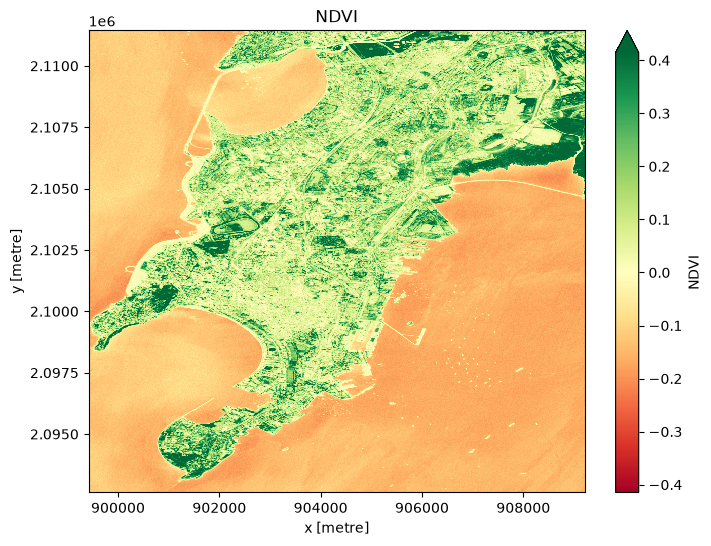

In [17]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

ndvi.plot(
    cmap="RdYlGn",
    robust=True
)

plt.title("NDVI")
plt.show()

In [18]:
print(imagery)

<xarray.Dataset> Size: 30MB
Dimensions:      (time: 1, y: 1882, x: 979)
Coordinates:
  * time         (time) datetime64[ns] 8B 2025-01-01T05:42:31.024000
  * y            (y) float64 15kB 2.111e+06 2.111e+06 ... 2.093e+06 2.093e+06
  * x            (x) float64 8kB 8.994e+05 8.994e+05 ... 9.092e+05 9.092e+05
Data variables:
    B02          (time, y, x) float32 7MB ...
    B03          (time, y, x) float32 7MB ...
    B04          (time, y, x) float32 7MB ...
    B08          (time, y, x) float32 7MB ...
    spatial_ref  int32 4B ...


# Terrain Indicator

## Purpose

Summarize the terrain characteristics of the Area of Interest.

The Terrain Indicator uses the terrain layers generated by the Terrain Engine to quantify elevation and slope characteristics that influence environmental processes and risk assessment.

In [19]:
terrain_indicator = {

    "Elevation": {

        "Minimum": round(
            float(
                terrain_layers["elevation"].min().values
            ),
            2
        ),

        "Maximum": round(
            float(
                terrain_layers["elevation"].max().values
            ),
            2
        ),

        "Mean": round(
            float(
                terrain_layers["elevation"].mean().values
            ),
            2
        )

    },

    "Slope": {

        "Minimum": round(
            float(
                terrain_layers["slope"].min().values
            ),
            2
        ),

        "Maximum": round(
            float(
                terrain_layers["slope"].max().values
            ),
            2
        ),

        "Mean": round(
            float(
                terrain_layers["slope"].mean().values
            ),
            2
        )

    }

}

terrain_indicator

{'Elevation': {'Minimum': -9.08, 'Maximum': 48.25, 'Mean': 5.64},
 'Slope': {'Minimum': 0.0, 'Maximum': 85.9, 'Mean': 30.74}}

# Land Cover Indicators

## Purpose

Summarize the land cover composition of the Area of Interest.

The Land Cover Indicator uses the standardized land cover statistics generated by the Land Cover Engine to characterize the Earth's surface.

In [20]:
land_cover_indicator = {

    "Dominant Class": land_cover_product["land_cover"]["dominant_class"],

    "Dominant Percentage": land_cover_product["land_cover"]["dominant_percentage"],

    "Summary": land_cover_product["land_cover"]["summary"]

}

land_cover_indicator

{'Dominant Class': 'Permanent Water',
 'Dominant Percentage': 59.24,
 'Summary': [{'class': 'Permanent Water',
   'area_km2': 135.6,
   'percentage': 59.24},
  {'class': 'Built-up', 'area_km2': 60.958, 'percentage': 26.63},
  {'class': 'Tree Cover', 'area_km2': 19.574, 'percentage': 8.55},
  {'class': 'Mangroves', 'area_km2': 4.184, 'percentage': 1.83},
  {'class': 'Bare / Sparse Vegetation', 'area_km2': 3.638, 'percentage': 1.59},
  {'class': 'Cropland', 'area_km2': 2.663, 'percentage': 1.16},
  {'class': 'Grassland', 'area_km2': 2.29, 'percentage': 1.0},
  {'class': 'Herbaceous Wetland', 'area_km2': 0.008, 'percentage': 0.0}]}

# Weather Indicators

## Purpose

Summarize the weather conditions over the selected analysis period.

The Weather Indicator derives representative temperature, precipitation, humidity, pressure, and wind statistics from the Weather Engine outputs.

In [21]:
weather_indicator = {

    "Temperature (°C)": {

        "Mean": round(
            weather_layers["temperature_2m_mean"].mean(),
            2
        )

    },

    "Precipitation (mm)": {

        "Total": round(
            weather_layers["precipitation_sum"].sum(),
            2
        )

    },

    "Humidity (%)": {

        "Mean": round(
            weather_layers["relative_humidity_2m_mean"].mean(),
            2
        )

    },

    "Pressure (hPa)": {

        "Mean": round(
            weather_layers["surface_pressure_mean"].mean(),
            2
        )

    },

    "Wind Speed (km/h)": {

        "Maximum": round(
            weather_layers["wind_speed_10m_max"].max(),
            2
        )

    }

}

weather_indicator

{'Temperature (°C)': {'Mean': np.float64(28.57)},
 'Precipitation (mm)': {'Total': np.float64(906.4)},
 'Humidity (%)': {'Mean': np.float64(78.9)},
 'Pressure (hPa)': {'Mean': np.float64(1005.02)},
 'Wind Speed (km/h)': {'Maximum': np.float64(41.4)}}

# Environmental Indicator Product

## Purpose

Create the standardized Environmental Indicator Product.

The Environmental Indicator Product combines vegetation, terrain, land cover, and weather indicators into a single structured product.

This product serves as the primary input for the Risk Assessment Engine.

In [23]:
from datetime import datetime

environmental_indicator_product = {

    "metadata": {

        "engine": "Environmental Indicator Engine",

        "version": "1.0",

        "created_at": datetime.now().strftime(
            "%Y-%m-%d %H:%M:%S"
        )

    },

    "summary": {

        "mean_ndvi": ndvi_summary["Mean"],

        "dominant_land_cover": land_cover_indicator["Dominant Class"],

        "mean_elevation": terrain_indicator["Elevation"]["Mean"],

        "mean_temperature": weather_indicator["Temperature (°C)"]["Mean"]

    },

    "vegetation": {

        "ndvi": ndvi_summary

    },

    "terrain": terrain_indicator,

    "land_cover": land_cover_indicator,

    "weather": weather_indicator

}

environmental_indicator_product

{'metadata': {'engine': 'Environmental Indicator Engine',
  'version': '1.0',
  'created_at': '2026-07-16 00:35:34'},
 'summary': {'mean_ndvi': -0.017,
  'dominant_land_cover': 'Permanent Water',
  'mean_elevation': 5.64,
  'mean_temperature': np.float64(28.57)},
 'vegetation': {'ndvi': {'Minimum': -0.23387940227985382,
   'Maximum': 0.6695563197135925,
   'Mean': -0.017,
   'Standard Deviation': 0.168}},
 'terrain': {'Elevation': {'Minimum': -9.08, 'Maximum': 48.25, 'Mean': 5.64},
  'Slope': {'Minimum': 0.0, 'Maximum': 85.9, 'Mean': 30.74}},
 'land_cover': {'Dominant Class': 'Permanent Water',
  'Dominant Percentage': 59.24,
  'Summary': [{'class': 'Permanent Water',
    'area_km2': 135.6,
    'percentage': 59.24},
   {'class': 'Built-up', 'area_km2': 60.958, 'percentage': 26.63},
   {'class': 'Tree Cover', 'area_km2': 19.574, 'percentage': 8.55},
   {'class': 'Mangroves', 'area_km2': 4.184, 'percentage': 1.83},
   {'class': 'Bare / Sparse Vegetation',
    'area_km2': 3.638,
    'perc

# Export Environmental Indicator Product

## Purpose

Export the outputs generated by the Environmental Indicator Engine.

The Environmental Indicator Product is exported as a JSON file for use by downstream Earth Intelligence modules.

In [24]:
from pathlib import Path
import json

OUTPUT_DIR = Path(
    "/Users/ShreyaJariwalaMain/_GeoAI_Notebook/Earth-Intelligence-System/data/outputs"
)

OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

environmental_indicator_product_file = (

    OUTPUT_DIR

    / "environmental_indicator_product.json"

)

with open(

    environmental_indicator_product_file,

    "w",

    encoding="utf-8"

) as file:

    json.dump(

        environmental_indicator_product,

        file,

        indent=4,

        default=str

    )

print(

    f"Environmental Indicator Product : "

    f"{environmental_indicator_product_file.name}"

)

Environmental Indicator Product : environmental_indicator_product.json


# Environmental Indicator Engine Summary

## Purpose

Summarize the environmental indicators generated for the selected Area of Interest.

This summary confirms that the Environmental Indicator Product was successfully created and is ready for downstream risk assessment.

In [25]:
summary = {

    "Mean NDVI": environmental_indicator_product["summary"]["mean_ndvi"],

    "Dominant Land Cover": (

        environmental_indicator_product["summary"]["dominant_land_cover"]

    ),

    "Mean Elevation (m)": (

        environmental_indicator_product["summary"]["mean_elevation"]

    ),

    "Mean Temperature (°C)": (

        environmental_indicator_product["summary"]["mean_temperature"]

    )

}

for key, value in summary.items():

    print(f"{key:<25}: {value}")

Mean NDVI                : -0.017
Dominant Land Cover      : Permanent Water
Mean Elevation (m)       : 5.64
Mean Temperature (°C)    : 28.57
